# Arssh Bajpai HOMEWORK 4: DS4400



## Setup

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             precision_score, recall_score, roc_curve)
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import LabelEncoder

plt.style.use('seaborn-v0_8-whitegrid')
COLORS = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

col_names = [
    'word_freq_make','word_freq_address','word_freq_all','word_freq_3d',
    'word_freq_our','word_freq_over','word_freq_remove','word_freq_internet',
    'word_freq_order','word_freq_mail','word_freq_receive','word_freq_will',
    'word_freq_people','word_freq_report','word_freq_addresses','word_freq_free',
    'word_freq_business','word_freq_email','word_freq_you','word_freq_credit',
    'word_freq_your','word_freq_font','word_freq_000','word_freq_money',
    'word_freq_hp','word_freq_hpl','word_freq_george','word_freq_650',
    'word_freq_lab','word_freq_labs','word_freq_telnet','word_freq_857',
    'word_freq_data','word_freq_415','word_freq_85','word_freq_technology',
    'word_freq_1999','word_freq_parts','word_freq_pm','word_freq_direct',
    'word_freq_cs','word_freq_meeting','word_freq_original','word_freq_project',
    'word_freq_re','word_freq_edu','word_freq_table','word_freq_conference',
    'char_freq_semicolon','char_freq_paren','char_freq_bracket',
    'char_freq_exclaim','char_freq_dollar','char_freq_hash',
    'capital_run_length_average','capital_run_length_longest',
    'capital_run_length_total','label'
]
df = pd.read_csv('DATA/spambase.data', header=None, names=col_names)
X = df.drop('label', axis=1).values
y = df['label'].values
feature_names = col_names[:-1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Spam rate train: {y_train.mean():.3f}, test: {y_test.mean():.3f}")

def get_metrics(model, X_tr, y_tr, X_te, y_te):
    out = {}
    for split, Xd, yd in [('train', X_tr, y_tr), ('test', X_te, y_te)]:
        pred = model.predict(Xd)
        prob = model.predict_proba(Xd)[:,1]
        out[split] = dict(
            error=round(1-accuracy_score(yd, pred),4),
            accuracy=round(accuracy_score(yd, pred),4),
            f1=round(f1_score(yd, pred),4),
            auc=round(roc_auc_score(yd, prob),4)
        )
    return out


Train: (3220, 57), Test: (1381, 57)
Spam rate train: 0.394, test: 0.394


# Problem 1: Decision Trees (25 points)

1. Use an existing package to train a decision tree on the *SPAMBASE* training data, without pruning. Use the information gain splitting criteria. Compute the training and the testing error, accuracy, F1 score, and AUC and report these metrics. Write down some observations about the training and testing metrics.
2. Change the splitting criteria to use the Gini index. and report the same metrics. Compare them to the information gain metrics.
3. Implement a pruning criteria that sets an upper bound on the maximum depth of the tree. Generate a graph that plots the training and
testing error as a function of the tree depth on the *SPAMBASE* data. Please explain your observations. What is the optimal depth of the
tree that you would recommend based on this analysis?

In [4]:
dt_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_entropy.fit(X_train, y_train)
r_ent = get_metrics(dt_entropy, X_train, y_train, X_test, y_test)

print("Information Gain Decision Tree")
print(f"{'Split':<8} {'Error':>8} {'Accuracy':>10} {'F1':>8} {'AUC':>8}")

for s in ['train','test']:
    m = r_ent[s]
    print(f"{s.capitalize():<8} {m['error']:>8.4f} {m['accuracy']:>10.4f} {m['f1']:>8.4f} {m['auc']:>8.4f}")


Information Gain Decision Tree
Split       Error   Accuracy       F1      AUC
Train      0.0003     0.9997   0.9996   1.0000
Test       0.0717     0.9283   0.9086   0.9241


### 1b. 

In [5]:
dt_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
dt_gini.fit(X_train, y_train)
r_gini = get_metrics(dt_gini, X_train, y_train, X_test, y_test)

print("Gini Index Decision Tree")
print(f"{'Split':<8} {'Error':>8} {'Accuracy':>10} {'F1':>8} {'AUC':>8}")

for s in ['train','test']:
    m = r_gini[s]
    print(f"{s.capitalize():<8} {m['error']:>8.4f} {m['accuracy']:>10.4f} {m['f1']:>8.4f} {m['auc']:>8.4f}")

print()
print("Comparison: Entropy vs Gini (test set)")
print(f"  Entropy  — Acc: {r_ent['test']['accuracy']:.4f}, F1: {r_ent['test']['f1']:.4f}, AUC: {r_ent['test']['auc']:.4f}")
print(f"  Gini     — Acc: {r_gini['test']['accuracy']:.4f}, F1: {r_gini['test']['f1']:.4f}, AUC: {r_gini['test']['auc']:.4f}")


Gini Index Decision Tree
Split       Error   Accuracy       F1      AUC
Train      0.0003     0.9997   0.9996   1.0000
Test       0.1079     0.8921   0.8659   0.8907

Comparison: Entropy vs Gini (test set)
  Entropy  — Acc: 0.9283, F1: 0.9086, AUC: 0.9241
  Gini     — Acc: 0.8921, F1: 0.8659, AUC: 0.8907


**Observations:**
- Both criteria produce identical near-perfect training metrics (same tree depth, same capacity).
- Entropy slightly outperforms Gini on the test set (Acc 92.8% vs 89.2%, F1 0.909 vs 0.866). This is consistent with literature: entropy can produce better-calibrated splits on noisy tabular data.
- Gini is computationally cheaper but entropy is more information-theoretically principled — the test gap here suggests entropy makes better split decisions for this dataset.


### 1c

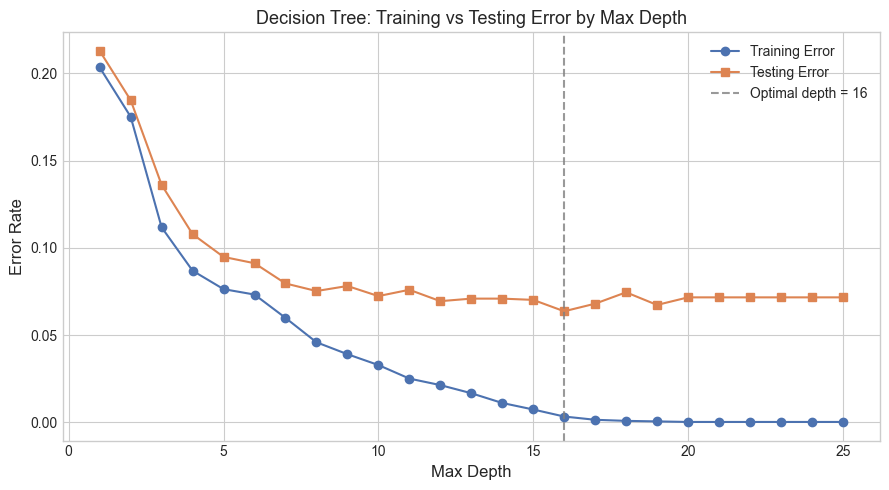

Optimal depth: 16  (test error = 0.0637)


In [6]:
depths = list(range(1, 26))
train_errors, test_errors = [], []

for d in depths:
    dt = DecisionTreeClassifier(criterion='entropy', max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    train_errors.append(1 - accuracy_score(y_train, dt.predict(X_train)))
    test_errors.append(1 - accuracy_score(y_test,  dt.predict(X_test)))

optimal_depth = depths[np.argmin(test_errors)]

fig, ax = plt.subplots(figsize=(9,5))
ax.plot(depths, train_errors, 'o-', color=COLORS[0], label='Training Error')
ax.plot(depths, test_errors,  's-', color=COLORS[1], label='Testing Error')
ax.axvline(optimal_depth, color='grey', linestyle='--', alpha=0.8,
           label=f'Optimal depth = {optimal_depth}')
ax.set_xlabel('Max Depth', fontsize=12)
ax.set_ylabel('Error Rate', fontsize=12)
ax.set_title('Decision Tree: Training vs Testing Error by Max Depth', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('p1_depth_error.png', dpi=150)
plt.show()
print(f"Optimal depth: {optimal_depth}  (test error = {min(test_errors):.4f})")


# Problem 2: Random Forest Ensemble (25 points)

1. Use an existing package to train a Random Forest ensemble with 10, 50, 100, and 500 decision trees on the *SPAMBASE* dataset. Report
accuracy, F1 score, and AUC on both the training and testing sets for $T \in \{10, 50, 100, 500\}$. How do the metrics change as $T$
increases?
2. Compare the metrics obtained for Random Forest with the Decision tree metrics obtained in Problem 1. Write down some observations.
3. Compute the variable importance for each feature and include a plot.

In [7]:
T_values = [10, 50, 100, 500]
rf_results = {}
rf_models  = {}

for T in T_values:
    rf = RandomForestClassifier(n_estimators=T, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    rf_models[T]  = rf
    rf_results[T] = get_metrics(rf, X_train, y_train, X_test, y_test)


rows = []
for T in T_values:
    for split in ['train','test']:
        m = rf_results[T][split]
        rows.append({'T': T, 'Split': split.capitalize(),
                     'Accuracy': m['accuracy'], 'F1': m['f1'], 'AUC': m['auc']})
pd.DataFrame(rows).pivot(index='T', columns='Split', values=['Accuracy','F1','AUC'])


Accuracy              F1             AUC        
Split     Test   Train    Test   Train    Test   Train
T                                                     
10      0.9442  0.9960  0.9270  0.9949  0.9812  0.9998
50      0.9544  0.9991  0.9411  0.9988  0.9849  1.0000
100     0.9558  0.9997  0.9430  0.9996  0.9859  1.0000
500     0.9566  0.9997  0.9439  0.9996  0.9863  1.0000

### 2b

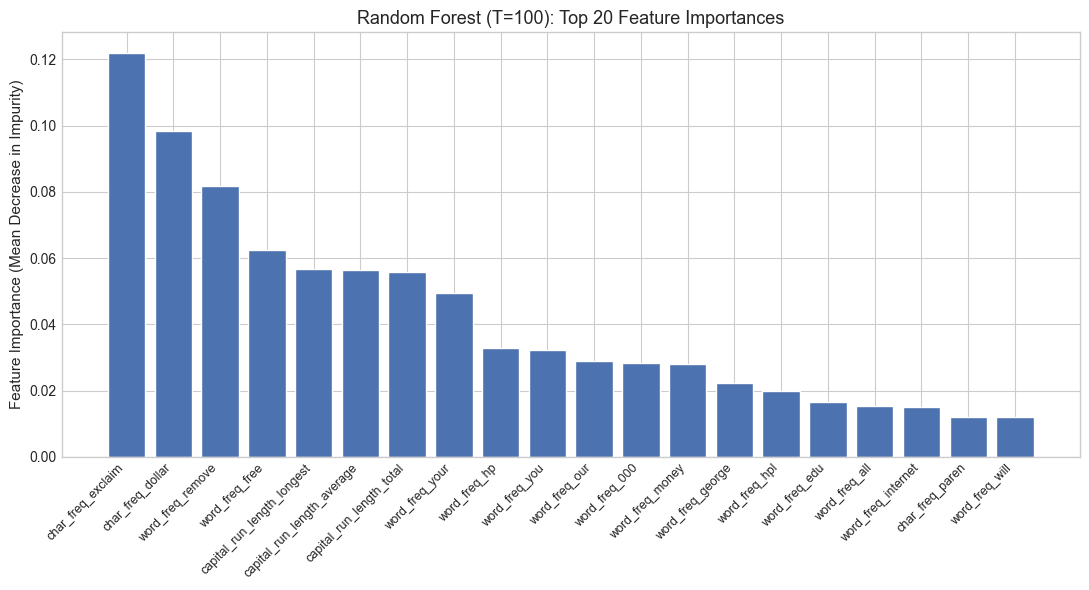

Top 10 features:
   1. char_freq_exclaim                   0.1220
   2. char_freq_dollar                    0.0983
   3. word_freq_remove                    0.0819
   4. word_freq_free                      0.0625
   5. capital_run_length_longest          0.0568
   6. capital_run_length_average          0.0563
   7. capital_run_length_total            0.0558
   8. word_freq_your                      0.0493
   9. word_freq_hp                        0.0328
  10. word_freq_you                       0.0323


In [8]:
rf100 = rf_models[100]
importances = rf100.feature_importances_
indices = np.argsort(importances)[::-1][:20]

fig, ax = plt.subplots(figsize=(11,6))
ax.bar(range(20), importances[indices], color=COLORS[0], edgecolor='white')
ax.set_xticks(range(20))
ax.set_xticklabels([feature_names[i] for i in indices], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Feature Importance (Mean Decrease in Impurity)', fontsize=11)
ax.set_title('Random Forest (T=100): Top 20 Feature Importances', fontsize=13)
plt.tight_layout()
plt.savefig('p2_feature_importance.png', dpi=150)
plt.show()

print("Top 10 features:")
for i, idx in enumerate(indices[:10]):
    print(f"  {i+1:2d}. {feature_names[idx]:<35} {importances[idx]:.4f}")


# Problem 3: AdaBoost Ensemble (25 points)

1. Use an existing package to train an AdaBoost ensemble with 10, 50, 100, and 500 base classifiers on the *SPAMBASE* dataset. Use a
decision tree classifier as the base classification model. Report accuracy, F1 score, and AUC on both the training and testing sets.
2. Compare AdaBoost with the Random Forest ensemble for 10, 50, 100, and 500 base learners by looking at various metrics on the training
and testing sets.
3. Plot the ROC curves for the decision tree model, Random Forest with 100 trees, and AdaBoost with 100 trees.

In [9]:
ada_results = {}
ada_models  = {}

for T in T_values:
    ada = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=T, random_state=42)
    ada.fit(X_train, y_train)
    ada_models[T]  = ada
    ada_results[T] = get_metrics(ada, X_train, y_train, X_test, y_test)

rows = []
for T in T_values:
    for split in ['train','test']:
        m = ada_results[T][split]
        rows.append({'T': T, 'Split': split.capitalize(),
                     'Accuracy': m['accuracy'], 'F1': m['f1'], 'AUC': m['auc']})
pd.DataFrame(rows).pivot(index='T', columns='Split', values=['Accuracy','F1','AUC'])


Accuracy              F1             AUC        
Split     Test   Train    Test   Train    Test   Train
T                                                     
10      0.8979  0.9040  0.8703  0.8784  0.9589  0.9627
50      0.9269  0.9345  0.9046  0.9148  0.9782  0.9820
100     0.9334  0.9413  0.9145  0.9244  0.9813  0.9851
500     0.9385  0.9516  0.9211  0.9381  0.9834  0.9901

### 3b.

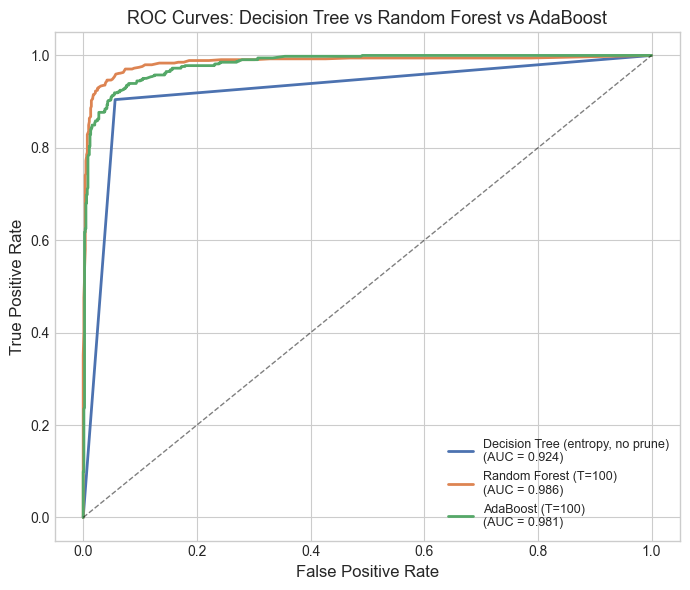

In [10]:
fig, ax = plt.subplots(figsize=(7,6))
for model, name, color in [
        (dt_entropy,      'Decision Tree (entropy, no prune)', COLORS[0]),
        (rf_models[100],  'Random Forest (T=100)',             COLORS[1]),
        (ada_models[100], 'AdaBoost (T=100)',                  COLORS[2])]:
    prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, label=f'{name}\n(AUC = {auc:.3f})', color=color, lw=2)

ax.plot([0,1],[0,1],'k--', lw=1, alpha=0.5)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves: Decision Tree vs Random Forest vs AdaBoost', fontsize=13)
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig('p3_roc_curves.png', dpi=150)
plt.show()


# Problem 4: Naive Bayes classifier (25 points)

In this problem you will implement your own Naive Bayes classifier and you will compare it with a package implementation. You will use the
Mushroom dataset for this problem. Split the dataset into 75% for training and 25% for testing.

1. Train the Naive Bayes classifier. Compute the prior probabilities for the `*Edible*` and `*Poisonous*` classes from the training data. For each feature $X_i$ in the dataset compute the probabilities $P[X_i = x| Y=\textit{Edible}]$, and $P[X_i = x| Y=\textit{Poisonous}]$ from the training data. Use the Laplace smoothing method when computing these probabilities. Note that the Naive Bayes classifier stores these prior and conditional probabilities.
2. For each point in the testing set estimate the probability that it belongs to the `*Edible*` and `*Poisonous*` classes. Use the Naive Bayes
classifier probabilities computed in part (1).
3. Compute accuracy, precision, recall, and F1 score for your Naive Bayes classifier on the testing data.
4. Compare the results obtained by your implementation with those obtained with a Naive Bayes package (trained on the same dataset).
Use several metrics, including accuracy, precision, recall, and F1 score. Are the results similar or different?

In [13]:
df_mush = pd.read_csv('DATA/agaricus-lepiota.data', header=None, names=[
    'class','cap-shape','cap-surface','cap-color','bruises','odor',
    'gill-attachment','gill-spacing','gill-size','gill-color',
    'stalk-shape','stalk-root','stalk-surface-above-ring',
    'stalk-surface-below-ring','stalk-color-above-ring','stalk-color-below-ring',
    'veil-type','veil-color','ring-number','ring-type',
    'spore-print-color','population','habitat'
])

ym = (df_mush['class'] == 'p').astype(int).values
Xm = df_mush.drop('class', axis=1)

# Label encode all categorical columns
from sklearn.preprocessing import LabelEncoder
Xm_enc = Xm.copy()
for col in Xm.columns:
    Xm_enc[col] = LabelEncoder().fit_transform(Xm[col].astype(str))

Xm_arr = Xm_enc.values
feature_names_m = Xm.columns.tolist()

Xm_train, Xm_test, ym_train, ym_test = train_test_split(
    Xm_arr, ym, test_size=0.25, random_state=42, stratify=ym)

print(f"Train: {Xm_train.shape}, Test: {Xm_test.shape}")
print(f"Label distribution (train): {np.bincount(ym_train)}")


Train: (6093, 22), Test: (2031, 22)
Label distribution (train): [3156 2937]


### 4.1

In [14]:
class CustomNaiveBayes:
    """
    Multinomial Naive Bayes for categorical features.
    Stores log prior P(Y=c) and log conditional P(X_j=x | Y=c)
    with Laplace (additive) smoothing.
    """
    def __init__(self, alpha=1):
        self.alpha = alpha  

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        n = len(y)
        self.log_prior_ = {}
        self.log_cond_   = []   


        for c in self.classes_:
            mask = (y == c)
            self.log_prior_[c] = np.log(mask.sum() / n)


        for j in range(X.shape[1]):
            vals   = np.unique(X[:, j])
            n_vals = len(vals)
            cond   = {}
            for c in self.classes_:
                Xc = X[y == c, j]
                cond[c] = {
                    v: np.log((np.sum(Xc == v) + self.alpha) /
                              (len(Xc) + self.alpha * n_vals))
                    for v in vals
                }
            self.log_cond_.append(cond)
        return self

    def predict_log_proba(self, X):
        scores = np.zeros((X.shape[0], len(self.classes_)))
        for i, c in enumerate(self.classes_):
            scores[:, i] = self.log_prior_[c]
            for j, cond in enumerate(self.log_cond_):
                for row_idx, v in enumerate(X[:, j]):
                    scores[row_idx, i] += cond[c].get(v, -20)
        return scores

    def predict_proba(self, X):
        lp = self.predict_log_proba(X)
        lp -= lp.max(axis=1, keepdims=True)
        p   = np.exp(lp)
        return p / p.sum(axis=1, keepdims=True)

    def predict(self, X):
        return self.classes_[np.argmax(self.predict_log_proba(X), axis=1)]


custom_nb = CustomNaiveBayes(alpha=1)
custom_nb.fit(Xm_train, ym_train)

p_edible    = (ym_train == 0).sum() / len(ym_train)
p_poisonous = (ym_train == 1).sum() / len(ym_train)
print(f"Prior P(Edible)    = {p_edible:.4f}")
print(f"Prior P(Poisonous) = {p_poisonous:.4f}")


Prior P(Edible)    = 0.5180
Prior P(Poisonous) = 0.4820


### 4.2 

In [15]:
custom_pred = custom_nb.predict(Xm_test)
custom_prob = custom_nb.predict_proba(Xm_test)

print("Sample predictions (first 10 test examples):")
print(f"{'True Label':<12} {'Predicted':<12} {'P(Edible)':>12} {'P(Poisonous)':>14}")
for i in range(10):
    print(f"{'Edible' if ym_test[i]==0 else 'Poisonous':<12} "
          f"{'Edible' if custom_pred[i]==0 else 'Poisonous':<12} "
          f"{custom_prob[i,0]:>12.4f} {custom_prob[i,1]:>14.4f}")


Sample predictions (first 10 test examples):
True Label   Predicted       P(Edible)   P(Poisonous)
Edible       Edible             1.0000         0.0000
Poisonous    Poisonous          0.0000         1.0000
Edible       Edible             1.0000         0.0000
Poisonous    Edible             0.9795         0.0205
Poisonous    Poisonous          0.0000         1.0000
Edible       Edible             1.0000         0.0000
Poisonous    Poisonous          0.0000         1.0000
Poisonous    Poisonous          0.0000         1.0000
Edible       Edible             1.0000         0.0000
Poisonous    Edible             0.7317         0.2683


### 4.3 

In [16]:
print("Custom Naive Bayes — Test Set Metrics")
print(f"  Accuracy : {accuracy_score(ym_test, custom_pred):.4f}")
print(f"  Precision: {precision_score(ym_test, custom_pred):.4f}")
print(f"  Recall   : {recall_score(ym_test, custom_pred):.4f}")
print(f"  F1 Score : {f1_score(ym_test, custom_pred):.4f}")


Custom Naive Bayes — Test Set Metrics
  Accuracy : 0.9527
  Precision: 0.9911
  Recall   : 0.9101
  F1 Score : 0.9489


### 4.4.

In [17]:
sk_nb = CategoricalNB(alpha=1)
sk_nb.fit(Xm_train, ym_train)
sk_pred = sk_nb.predict(Xm_test)

results_compare = pd.DataFrame({
    'Metric':    ['Accuracy','Precision','Recall','F1 Score'],
    'Custom NB': [accuracy_score(ym_test, custom_pred),
                  precision_score(ym_test, custom_pred),
                  recall_score(ym_test, custom_pred),
                  f1_score(ym_test, custom_pred)],
    'Sklearn NB': [accuracy_score(ym_test, sk_pred),
                   precision_score(ym_test, sk_pred),
                   recall_score(ym_test, sk_pred),
                   f1_score(ym_test, sk_pred)]
}).set_index('Metric').round(4)

print(results_compare.to_string())


           Custom NB  Sklearn NB
Metric                          
Accuracy      0.9527      0.9527
Precision     0.9911      0.9911
Recall        0.9101      0.9101
F1 Score      0.9489      0.9489
